# Machine Learning & Feature Engineering for Time Series Forecasting 🤖📈

Welcome to the **Machine Learning & Feature Engineering** guide. While traditional statistical methods (like ARIMA) are highly effective, modern machine learning algorithms (like Gradient Boosted Trees: XGBoost, LightGBM) are the industry workhorses for complex time series problems due to their capability to scale, handle tabular features, and model non-linear relationships.

In this notebook, we will cover:
1. **Supervised Learning Formulation:** Re-framing a time series sequence into a tabular dataset using the sliding window approach.
2. **Feature Engineering:** Building powerful predictive inputs (Lags, Window Statistics, Temporal Features, Cyclical Encodings).
3. **Validation Strategy:** Understanding why standard cross-validation fails and implementing `TimeSeriesSplit`.
4. **Modeling & Prediction:** Training **XGBoost** and **LightGBM** models and evaluating them using walk-forward validation.

---

## 🍷 Dataset: Alcohol Sales
We will use the `data/Alcohol_Sales.csv` dataset, which contains monthly industrial alcohol sales. It exhibits a strong upward trend and clear annual seasonality.

## 🛠️ 1. Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("XGBoost version:", xgb.__version__)
print("LightGBM version:", lgb.__version__)

XGBoost version: 2.1.0
LightGBM version: 4.4.0


## 📥 2. Load & Explore Data

            Sales
DATE             
1992-01-01   3459
1992-02-01   3458
1992-03-01   4002
1992-04-01   4564
1992-05-01   4221

Dataset shape: (325, 1)


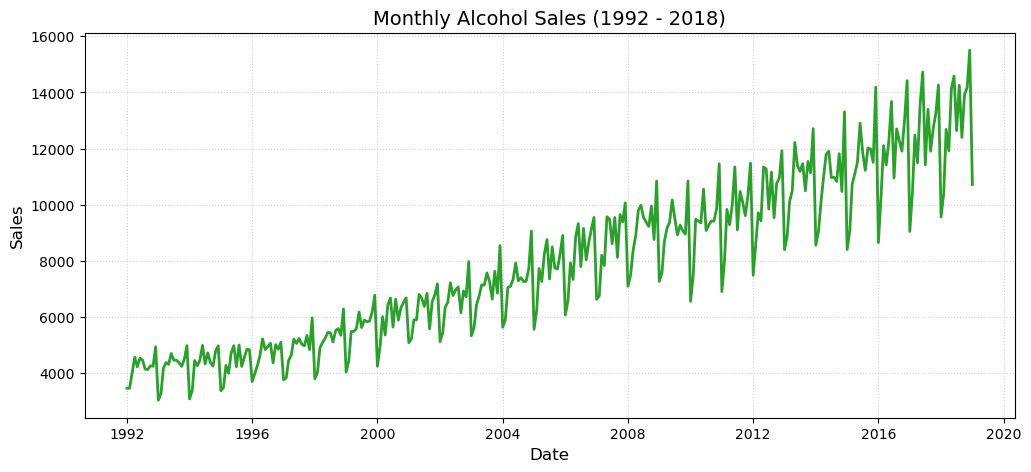

In [2]:
df = pd.read_csv('data/Alcohol_Sales.csv', parse_dates=['DATE'], index_col='DATE')
df.columns = ['Sales']
df.index.freq = 'MS' # Monthly Start frequency

print(df.head())
print(f"\nDataset shape: {df.shape}")

# Plot the series
plt.figure(figsize=(12, 5))
plt.plot(df['Sales'], color='#2ca02c', lw=2)
plt.title('Monthly Alcohol Sales (1992 - 2018)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 🛠️ 3. Feature Engineering

To use machine learning models, we convert the index dates and historical target values into tabular columns.

In [3]:
def create_features(data):
    df_feats = data.copy()
    
    # 1. Temporal Datetime Features
    df_feats['Month'] = df_feats.index.month
    df_feats['Year'] = df_feats.index.year
    
    # 2. Cyclical Encodings (sine/cosine representation of month to capture continuous seasonal transitions)
    df_feats['Month_sin'] = np.sin(df_feats['Month'] * (2 * np.pi / 12))
    df_feats['Month_cos'] = np.cos(df_feats['Month'] * (2 * np.pi / 12))
    
    # 3. Lag Features (values from previous months)
    df_feats['Lag_1'] = df_feats['Sales'].shift(1)
    df_feats['Lag_2'] = df_feats['Sales'].shift(2)
    df_feats['Lag_3'] = df_feats['Sales'].shift(3)
    df_feats['Lag_12'] = df_feats['Sales'].shift(12) # Same month previous year (critical for annual seasonality)
    
    # 4. Rolling Window Features
    df_feats['Rolling_Mean_3'] = df_feats['Sales'].shift(1).rolling(window=3).mean()
    df_feats['Rolling_Std_3'] = df_feats['Sales'].shift(1).rolling(window=3).std()
    df_feats['Rolling_Mean_6'] = df_feats['Sales'].shift(1).rolling(window=6).mean()
    df_feats['Rolling_Std_6'] = df_feats['Sales'].shift(1).rolling(window=6).std()
    df_feats['Rolling_Mean_12'] = df_feats['Sales'].shift(1).rolling(window=12).mean()
    
    return df_feats

df_features = create_features(df)

# Since we have lags of up to 12 steps, the first 12 rows will contain NaNs.
# We drop them to ensure clean inputs for our machine learning models.
df_features = df_features.dropna()
print(df_features.head())
print(f"\nShape after feature engineering and dropping NaNs: {df_features.shape}")

            Sales  Month  Year  Month_sin     Month_cos   Lag_1   Lag_2  \
DATE                                                                      
1993-01-01   3031      1  1993   0.500000  8.660254e-01  4936.0  4240.0   
1993-02-01   3261      2  1993   0.866025  5.000000e-01  3031.0  4936.0   
1993-03-01   4160      3  1993   1.000000  6.123234e-17  3261.0  3031.0   
1993-04-01   4377      4  1993   0.866025 -5.000000e-01  4160.0  3261.0   
1993-05-01   4307      5  1993   0.500000 -8.660254e-01  4377.0  4160.0   

             Lag_3  Lag_12  Rolling_Mean_3  Rolling_Std_3  Rolling_Mean_6  \
DATE                                                                        
1993-01-01  4259.0  3459.0     4478.333333     396.464795     4360.666667   
1993-02-01  4240.0  3458.0     4069.000000     963.943463     4121.500000   
1993-03-01  4936.0  4002.0     3742.666667    1039.835724     3975.500000   
1993-04-01  3031.0  4564.0     3484.000000     596.621320     3981.166667   
1993-05-01  

## 🎯 4. Validation Strategy

Standard K-fold cross-validation is **invalid** for time series because it shuffles data, leading to **data leakage** (using future information to predict the past). 

We must use a time-series split (`TimeSeriesSplit`), which respects temporal ordering by progressively moving the validation window forward.

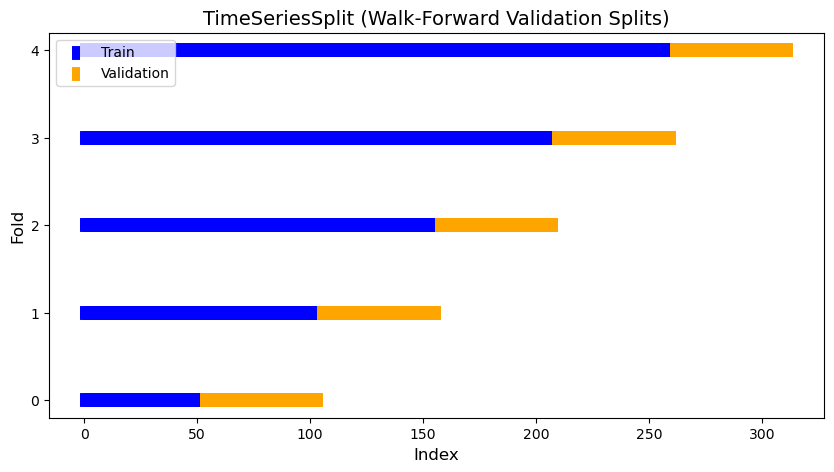

In [4]:
tscv = TimeSeriesSplit(n_splits=5)

fig, ax = plt.subplots(figsize=(10, 5))
for fold, (train_indices, val_indices) in enumerate(tscv.split(df_features)):
    # Visualizing train vs val splits
    ax.scatter(train_indices, [fold] * len(train_indices), color='blue', marker='_', lw=10, label='Train' if fold == 0 else "")
    ax.scatter(val_indices, [fold] * len(val_indices), color='orange', marker='_', lw=10, label='Validation' if fold == 0 else "")

ax.set_title('TimeSeriesSplit (Walk-Forward Validation Splits)', fontsize=14)
ax.set_xlabel('Index', fontsize=12)
ax.set_ylabel('Fold', fontsize=12)
ax.set_yticks(range(5))
ax.legend(loc='upper left')
plt.show()

## 🌲 5. Baseline Modeling (Train/Test Split)

Let's split the dataset chronologically: the last **24 months** will be used as the test set, and everything prior will be the training set.

In [5]:
# Splitting last 24 months for test set
test_size = 24
train_data = df_features.iloc[:-test_size]
test_data = df_features.iloc[-test_size:]

# Separate target and features
feature_cols = [
    'Month', 'Year', 'Month_sin', 'Month_cos', 
    'Lag_1', 'Lag_2', 'Lag_3', 'Lag_12', 
    'Rolling_Mean_3', 'Rolling_Std_3', 'Rolling_Mean_6', 'Rolling_Std_6', 'Rolling_Mean_12'
]

X_train, y_train = train_data[feature_cols], train_data['Sales']
X_test, y_test = test_data[feature_cols], test_data['Sales']

print(f"Train shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test shape: X={X_test.shape}, y={y_test.shape}")

Train shape: X=(289, 13), y=(289,)
Test shape: X=(24, 13), y=(24,)


### XGBoost Regressor

In [6]:
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict
xgb_preds = xgb_model.predict(X_test)

# Evaluate
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = mean_squared_error(y_test, xgb_preds, squared=False)
xgb_mape = mean_absolute_percentage_error(y_test, xgb_preds)

print(f"XGBoost Test Metrics:")
print(f"  MAE:  {xgb_mae:.2f}")
print(f"  RMSE: {xgb_rmse:.2f}")
print(f"  MAPE: {xgb_mape:.4%}")

XGBoost Test Metrics:
  MAE:  853.72
  RMSE: 1105.04
  MAPE: 6.3823%


### LightGBM Regressor

In [7]:
lgb_model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)

# Predict
lgb_preds = lgb_model.predict(X_test)

# Evaluate
lgb_mae = mean_absolute_error(y_test, lgb_preds)
lgb_rmse = mean_squared_error(y_test, lgb_preds, squared=False)
lgb_mape = mean_absolute_percentage_error(y_test, lgb_preds)

print(f"LightGBM Test Metrics:")
print(f"  MAE:  {lgb_mae:.2f}")
print(f"  RMSE: {lgb_rmse:.2f}")
print(f"  MAPE: {lgb_mape:.4%}")

LightGBM Test Metrics:
  MAE:  1037.41
  RMSE: 1301.00
  MAPE: 7.7402%


## 📈 6. Walk-Forward Validation (Recursive Forecasting)

When predicting a long horizon (e.g. 24 months), standard single-step modeling suffers from predicting off *predicted* features. Walk-forward validation mimics the real-world scenario where, at each month, we make a prediction and update the model with the true observed values once they become available.

In [8]:
# We will perform walk-forward validation recursively for XGBoost
history_data = df_features.iloc[:-test_size].copy()
wf_predictions = []

for i in range(test_size):
    # Features of the test step we want to predict
    current_test_step = df_features.iloc[[-test_size + i]]
    X_wf = current_test_step[feature_cols]
    
    # Retrain XGBoost model with historical data up to this step
    X_train_wf = history_data[feature_cols]
    y_train_wf = history_data['Sales']
    
    model_wf = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
    model_wf.fit(X_train_wf, y_train_wf)
    
    # Predict
    pred = model_wf.predict(X_wf)[0]
    wf_predictions.append(pred)
    
    # Add the current true test step to history for the next iteration
    history_data = pd.concat([history_data, current_test_step])

# Metrics for Walk-Forward Forecasting
wf_mae = mean_absolute_error(y_test, wf_predictions)
wf_rmse = mean_squared_error(y_test, wf_predictions, squared=False)
wf_mape = mean_absolute_percentage_error(y_test, wf_predictions)

print(f"XGBoost Walk-Forward Metrics:")
print(f"  MAE:  {wf_mae:.2f}")
print(f"  RMSE: {wf_rmse:.2f}")
print(f"  MAPE: {wf_mape:.4%}")

XGBoost Walk-Forward Metrics:
  MAE:  593.64
  RMSE: 764.09
  MAPE: 4.5460%


## 📊 7. Visualization of Forecasts

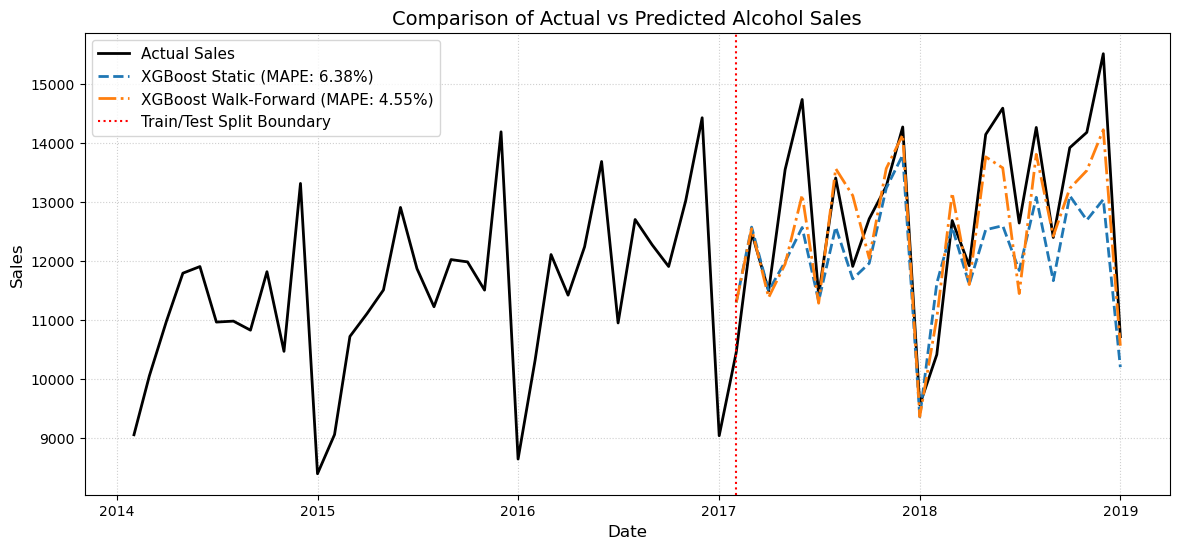

In [9]:
plt.figure(figsize=(14, 6))

# Plot the last year of train data and test data
plt.plot(df.index[-60:], df['Sales'].iloc[-60:], label='Actual Sales', color='black', lw=2)
plt.plot(y_test.index, xgb_preds, label=f'XGBoost Static (MAPE: {xgb_mape:.2%})', color='#1f77b4', lw=2, linestyle='--')
plt.plot(y_test.index, wf_predictions, label=f'XGBoost Walk-Forward (MAPE: {wf_mape:.2%})', color='#ff7f0e', lw=2, linestyle='-.')

plt.title('Comparison of Actual vs Predicted Alcohol Sales', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.axvline(x=y_test.index[0], color='red', linestyle=':', label='Train/Test Split Boundary')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.show()

## 💡 8. Summary & Best Practices

- **Lags are Critical:** Lag features (especially matching seasonality like `Lag_12` for monthly data) convey past periodic patterns directly to trees.
- **Walk-Forward Validation:** While static splits are fast, walk-forward validation represents a realistic estimate of validation performance since models are continuously updated in production.
- **Tree Limitations:** Tree-based models (XGBoost/LightGBM) **cannot extrapolate trends** (they cannot output values larger than the maximum value in the training set). If your series has a steep trend, it is best to first difference the series, train the tree model on the stationary differences, and then reconstruct the trend!